In [ ]:
import os, re
from glob import glob
from pathlib import Path
import random
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as F
from torchvision.transforms import InterpolationMode
import numpy as np
from torchvision import transforms
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
from torchvision.transforms import functional as TF
import random

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Set device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda:0


In [ ]:
# ---- Directories ----
train_image_dirs = [
    "RETA_data/images/train/img",
    "CHASE DB/CHASE DB/Image", 
    "HRF_data/images",
    "Five Fundus/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/train/Original/Original"
]

train_mask_dirs = [
    "RETA_data/images/train/vessel",
    "CHASE DB/CHASE DB/Lable",
    "HRF_data/manual1",
    "Five Fundus/FIVES A Fundus Image Dataset for AI-based Vessel Segmentation/train/Ground truth"
]

test_image_dirs = ["DRIVE Dataset/DRIVE/training/images"]
test_mask_dirs  = ["DRIVE Dataset/DRIVE/training/1st_manual"]

image_extensions = ('*.tif','*.tiff','*.png','*.jpg','*.jpeg','*.gif','*.JPG','*.bmp')

import re
from pathlib import Path

_TOKENS_TO_STRIP = {
    "vessel", "manual1", "manual2", "manual", "label", "labels", "lable",
    "mask", "gt", "groundtruth", "training", "test", "1st_manual", "2nd_manual"
}

def canonical_key(path_like: str) -> str:
    """
    Build a stable key from filename stem by splitting on separators and
    removing entire tokens that match tokens to strip (including suffix digits).
    Returns a lowercase alphanumeric-only concatenation of retained tokens.
    """
    stem = Path(path_like).stem.lower()
    tokens = re.split(r'[_\-\.\s]+', stem)
    kept = []
    for t in tokens:
        if not t:
            continue
        skip = False
        for tok in _TOKENS_TO_STRIP:
            if t == tok or re.fullmatch(rf"{re.escape(tok)}\d+", t):
                skip = True
                break
        if not skip:
            cleaned = re.sub(r'[^a-z0-9]', '', t)
            if cleaned:
                kept.append(cleaned)
    return ''.join(kept)

def gather_pairs(img_dirs, mask_dirs, exts, debug=False):
    image_paths, mask_paths = [], []
    for img_dir, msk_dir in zip(img_dirs, mask_dirs):
        imgs, msks = [], []
        for e in exts:
            imgs.extend(glob(os.path.join(img_dir, e)))
            msks.extend(glob(os.path.join(msk_dir, e)))

        img_map = {}
        for p in imgs:
            k = canonical_key(p)
            img_map[k] = p

        msk_map = {}
        for p in msks:
            k = canonical_key(p)
            msk_map[k] = p

        common = sorted(set(img_map.keys()) & set(msk_map.keys()))
        if debug:
            print(f"[DEBUG] Dir pair:\n  IMG: {img_dir}\n  MSK: {msk_dir}")
            print(f"  Found imgs={len(imgs)} msks={len(msks)} -> paired={len(common)}")
            if len(common) == 0:
                # show a few sample keys to diagnose
                print("  Sample IMG keys:", list(sorted(img_map.keys()))[:5])
                print("  Sample MSK keys:", list(sorted(msk_map.keys()))[:5])

        image_paths.extend([img_map[k] for k in common])
        mask_paths.extend([msk_map[k] for k in common])

    return image_paths, mask_paths

class JointTransform:
    def __init__(self, size=512, train=True, degrees=15, hflip_p=0.5, vflip_p=0.0, color_jitter=(0.2,0.2,0.2,0.05)):
        """
        color_jitter: (brightness, contrast, saturation, hue)
        Uses TF (from torchvision.transforms.functional) for image ops.
        """
        self.size = size
        self.train = train
        self.degrees = degrees
        self.hflip_p = hflip_p
        self.vflip_p = vflip_p
        self.color_jitter = color_jitter

    def __call__(self, img, mask):
        # Resize (PIL Image -> PIL Image)
        img  = TF.resize(img,  (self.size, self.size), InterpolationMode.BILINEAR)
        mask = TF.resize(mask, (self.size, self.size), InterpolationMode.NEAREST)

        if self.train:
            # geometric transforms
            if random.random() < self.hflip_p:
                img = TF.hflip(img); mask = TF.hflip(mask)
            if random.random() < self.vflip_p:
                img = TF.vflip(img); mask = TF.vflip(mask)

            angle = random.uniform(-self.degrees, self.degrees)
            img  = TF.rotate(img, angle, InterpolationMode.BILINEAR)
            mask = TF.rotate(mask, angle, InterpolationMode.NEAREST)

            # color jitter (applied to image only)
            b, c, s, h = self.color_jitter
            if random.random() < 0.9:
                if b > 0:
                    img = TF.adjust_brightness(img, 1.0 + random.uniform(-b, b))
                if c > 0:
                    img = TF.adjust_contrast(img,   1.0 + random.uniform(-c, c))
                if s > 0:
                    img = TF.adjust_saturation(img, 1.0 + random.uniform(-s, s))
                if h > 0:
                    img = TF.adjust_hue(img, random.uniform(-h, h))

        # ToTensor + Normalize (image)
        img = TF.to_tensor(img)
        img = TF.normalize(img, mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])

        # Mask -> tensor and binarize
        mask = TF.to_tensor(mask)          # [1,H,W] in [0,1]
        mask = (mask > 0.5).float()       # binarize
        return img, mask

# Dataset
class RetinalDataset(Dataset):
    def __init__(self, image_paths, mask_paths, joint_transform):
        assert len(image_paths) == len(mask_paths), "Mismatched image/mask counts"
        self.imgs = image_paths
        self.msks = mask_paths
        self.t = joint_transform

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        img  = Image.open(self.imgs[i]).convert("RGB")
        msk  = Image.open(self.msks[i]).convert("L")
        return self.t(img, msk)

# Loader builder (FIXED SPLIT)
def build_loaders(batch_size=4, size=512, val_split=0.2, seed=42):
    # Gather pairs
    train_imgs_all, train_msks_all = gather_pairs(train_image_dirs, train_mask_dirs, image_extensions)
    test_imgs_all,  test_msks_all  = gather_pairs(test_image_dirs,  test_mask_dirs,  image_extensions)
    print(f"Train pairs: {len(train_imgs_all)}, Test pairs: {len(test_imgs_all)}")

    if len(train_imgs_all) == 0:
        raise RuntimeError("No training pairs found. Check paths/extensions.")

    # Create a stable random split WITHOUT overwriting the original lists
    n = len(train_imgs_all)
    rng = random.Random(seed)
    indices = list(range(n))
    rng.shuffle(indices)
    split = int(n * (1 - val_split))
    train_idx = indices[:split]
    val_idx   = indices[split:]

    tr_imgs = [train_imgs_all[i] for i in train_idx]
    tr_msks = [train_msks_all[i] for i in train_idx]
    va_imgs = [train_imgs_all[i] for i in val_idx]
    va_msks = [train_msks_all[i] for i in val_idx]

    # Transforms
    jt_train = JointTransform(size=size, train=True)
    jt_eval  = JointTransform(size=size, train=False)

    # Datasets
    ds_tr = RetinalDataset(tr_imgs, tr_msks, jt_train)
    ds_va = RetinalDataset(va_imgs, va_msks, jt_eval)

    # Loaders
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    dl_va = DataLoader(ds_va, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    dl_te = None
    if len(test_imgs_all) > 0:
        ds_te = RetinalDataset(test_imgs_all, test_msks_all, jt_eval)
        dl_te = DataLoader(ds_te, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

    return dl_tr, dl_va, dl_te


train_loader, val_loader, test_loader = build_loaders()
print(f"Total training samples:   {len(train_loader.dataset)}")
print(f"Total validation samples: {len(val_loader.dataset)}")
print(f"Total test samples:       {0 if test_loader is None else len(test_loader.dataset)}")

Train pairs: 699, Test pairs: 20
Total training samples:   559
Total validation samples: 140
Total test samples:       20


In [4]:
import torch

def create_patches(images, masks, patch_size=128, stride=64, min_foreground=1, return_coords=False):
    """
    images: torch.Tensor [N, C, H, W]
    masks:  torch.Tensor [N, 1, H, W]
    Returns:
      - img_patches: [M, C, patch_size, patch_size]
      - mask_patches: [M, 1, patch_size, patch_size]
      - (optional) coords: list of (img_index, y, x) for each patch (scanline order)
    """
    img_patches = []
    mask_patches = []
    coords = []
    N, C, H, W = images.shape

    for i in range(N):
        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                mp = masks[i, :, y:y+patch_size, x:x+patch_size]
                if mp.sum() >= min_foreground:
                    ip = images[i, :, y:y+patch_size, x:x+patch_size]
                    img_patches.append(ip.unsqueeze(0))
                    mask_patches.append(mp.unsqueeze(0))
                    coords.append((i, y, x))

    if len(img_patches) == 0:
        empty_imgs = torch.empty(0, images.size(1), patch_size, patch_size, dtype=images.dtype)
        empty_msks = torch.empty(0, masks.size(1), patch_size, patch_size, dtype=masks.dtype)
        if return_coords:
            return empty_imgs, empty_msks, []
        return empty_imgs, empty_msks

    imgs_cat = torch.cat(img_patches, dim=0)
    msks_cat = torch.cat(mask_patches, dim=0)
    if return_coords:
        return imgs_cat, msks_cat, coords
    return imgs_cat, msks_cat

In [5]:
train_images, train_masks = [], []
val_images, val_masks = [], []

# Gather all train samples into memory
for imgs, msks in train_loader:
    train_images.append(imgs)
    train_masks.append(msks)

train_images = torch.cat(train_images, dim=0)
train_masks  = torch.cat(train_masks, dim=0)

# Same for validation
for imgs, msks in val_loader:
    val_images.append(imgs)
    val_masks.append(msks)

val_images = torch.cat(val_images, dim=0)
val_masks  = torch.cat(val_masks, dim=0)

train_img_patches, train_mask_patches = create_patches(train_images, train_masks)
val_img_patches, val_mask_patches     = create_patches(val_images, val_masks)

print(f"Training image patches: {train_img_patches.shape}")
print(f"Training mask patches:  {train_mask_patches.shape}")
print(f"Validation image patches: {val_img_patches.shape}")
print(f"Validation mask patches:  {val_mask_patches.shape}")

Training image patches: torch.Size([26899, 3, 128, 128])
Training mask patches:  torch.Size([26899, 1, 128, 128])
Validation image patches: torch.Size([6713, 3, 128, 128])
Validation mask patches:  torch.Size([6713, 1, 128, 128])


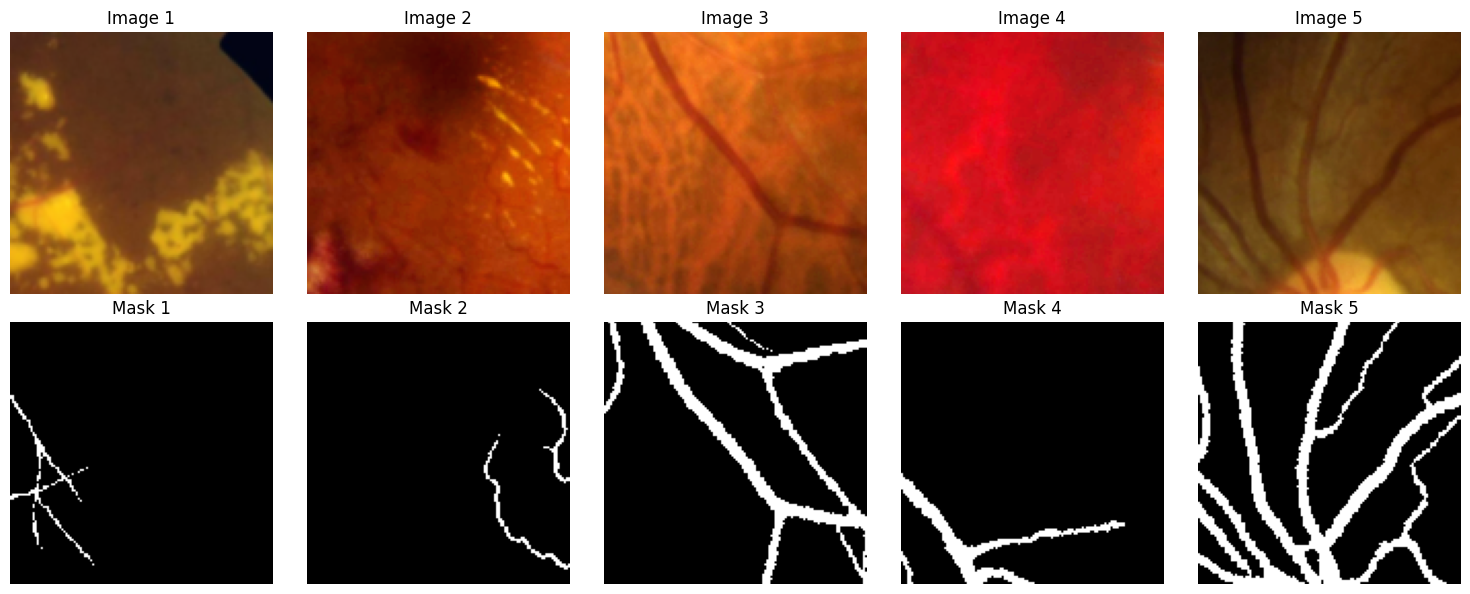

In [6]:
num_samples = 5
fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))

# Select random indices
indices = np.random.choice(len(train_img_patches), num_samples, replace=False)

for i, idx in enumerate(indices):
    # Plot image
    img = train_img_patches[idx].permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())  # Normalize for visualization
    axes[0,i].imshow(img)
    axes[0,i].axis('off')
    axes[0,i].set_title(f'Image {i+1}')
    
    # Plot mask
    mask = train_mask_patches[idx].squeeze().cpu().numpy()
    axes[1,i].imshow(mask, cmap='gray')
    axes[1,i].axis('off')
    axes[1,i].set_title(f'Mask {i+1}')

plt.tight_layout()
plt.show()

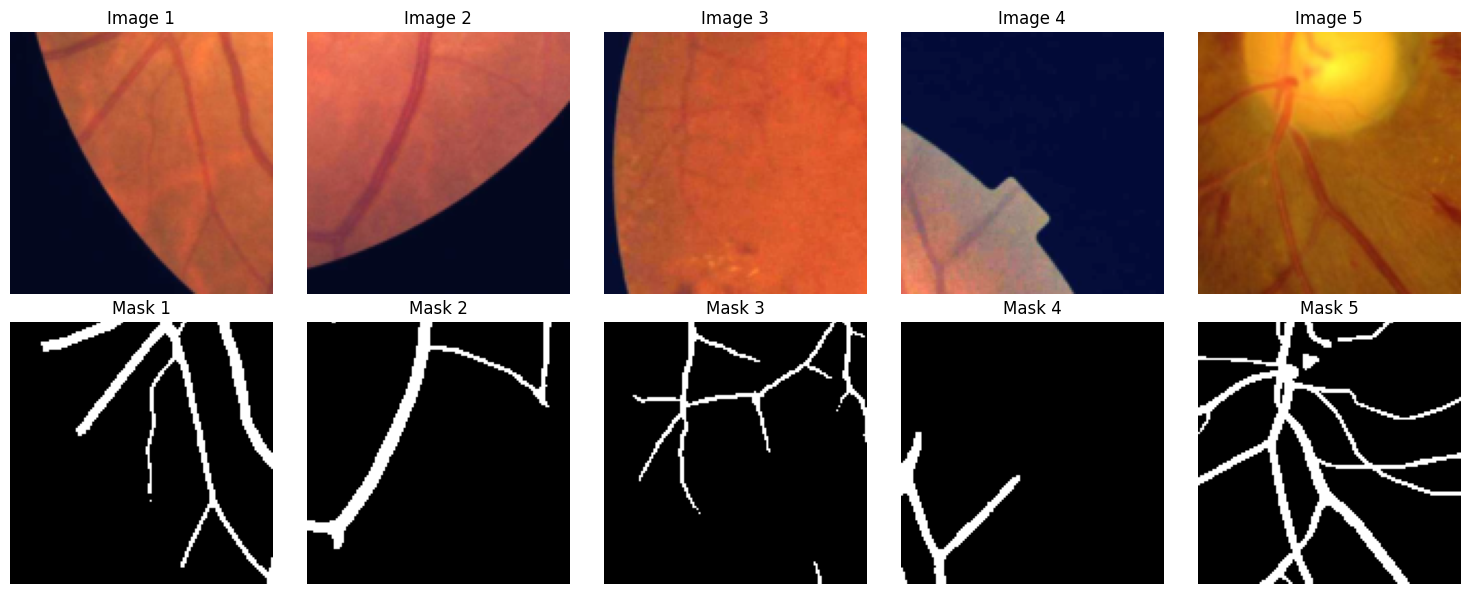

In [7]:
num_samples = 5
fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))

# Select random indices
indices = np.random.choice(len(val_img_patches), num_samples, replace=False)

for i, idx in enumerate(indices):
    # Plot image
    img = val_img_patches[idx].permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min())  # Normalize for visualization
    axes[0,i].imshow(img)
    axes[0,i].axis('off')
    axes[0,i].set_title(f'Image {i+1}')
    
    # Plot mask
    mask = val_mask_patches[idx].squeeze().cpu().numpy()
    axes[1,i].imshow(mask, cmap='gray')
    axes[1,i].axis('off')
    axes[1,i].set_title(f'Mask {i+1}')

plt.tight_layout()
plt.show()

In [8]:

import torch.nn as nn

def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.kaiming_normal_(m.weight, a=0.2)
        if m.bias is not None:
            nn.init.zeros_(m.bias)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.ones_(m.weight)
        nn.init.zeros_(m.bias)

class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=64, use_dropout=False):
        super(Generator, self).__init__()
        self.encoder1 = self.conv_block(in_channels, features)
        self.encoder2 = self.conv_block(features, features * 2)
        self.encoder3 = self.conv_block(features * 2, features * 4)
        self.encoder4 = self.conv_block(features * 4, features * 8)
        self.bottleneck = self.conv_block(features * 8, features * 16)
        self.upconv4 = nn.ConvTranspose2d(features * 16, features * 8, kernel_size=2, stride=2)
        self.decoder4 = self.conv_block(features * 16, features * 8)
        self.upconv3 = nn.ConvTranspose2d(features * 8, features * 4, kernel_size=2, stride=2)
        self.decoder3 = self.conv_block(features * 8, features * 4)
        self.upconv2 = nn.ConvTranspose2d(features * 4, features * 2, kernel_size=2, stride=2)
        self.decoder2 = self.conv_block(features * 4, features * 2)
        self.upconv1 = nn.ConvTranspose2d(features * 2, features, kernel_size=2, stride=2)
        self.decoder1 = self.conv_block(features * 2, features)
        self.final_conv = nn.Conv2d(features, out_channels, kernel_size=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.sigmoid = nn.Sigmoid()
        self.apply(init_weights)

    def conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        enc1 = self.encoder1(x)
        enc2 = self.encoder2(self.pool(enc1))
        enc3 = self.encoder3(self.pool(enc2))
        enc4 = self.encoder4(self.pool(enc3))
        bottleneck = self.bottleneck(self.pool(enc4))
        dec4 = self.upconv4(bottleneck)
        dec4 = torch.cat((dec4, enc4), dim=1)
        dec4 = self.decoder4(dec4)
        dec3 = self.upconv3(dec4)
        dec3 = torch.cat((dec3, enc3), dim=1)
        dec3 = self.decoder3(dec3)
        dec2 = self.upconv2(dec3)
        dec2 = torch.cat((dec2, enc2), dim=1)
        dec2 = self.decoder2(dec2)
        dec1 = self.upconv1(dec2)
        dec1 = torch.cat((dec1, enc1), dim=1)
        dec1 = self.decoder1(dec1)
        out = self.final_conv(dec1)
        # For training use logits and apply sigmoid only for visualization/metrics
        return out

class Discriminator(nn.Module):
    def __init__(self, in_channels=4, features=64):  # 3 (image) + 1 (mask) = 4 channels
        super(Discriminator, self).__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(in_channels, features, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.down1 = self.discriminator_block(features, features * 2)
        self.down2 = self.discriminator_block(features * 2, features * 4)
        self.down3 = self.discriminator_block(features * 4, features * 8)
        # final conv -> single-channel logit (no sigmoid)
        self.final = nn.Conv2d(features * 8, 1, kernel_size=4, stride=1, padding=1)
        self.apply(init_weights)

    def discriminator_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2, inplace=True)
        )

    def forward(self, image, mask):
        x = torch.cat([image, mask], dim=1)
        x = self.initial(x)
        x = self.down1(x)
        x = self.down2(x)
        x = self.down3(x)
        x = self.final(x)  # logits
        return x

# Combines the generator and discriminator into one model class for clean code organization and forward pass abstraction.
class RVGAN(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, generator_features=64, discriminator_features=64):
        super(RVGAN, self).__init__()
        self.generator = Generator(in_channels, out_channels, generator_features)
        self.discriminator = Discriminator(in_channels + out_channels, discriminator_features)
    
    def forward(self, x):
        return self.generator(x)

import torch.nn.functional as F

class RVGANLoss(nn.Module):
    def __init__(self, lambda_l1=100.0, lambda_dice=10.0, real_label_smooth=0.9):
        super(RVGANLoss, self).__init__()
        self.lambda_l1 = lambda_l1
        self.lambda_dice = lambda_dice
        self.real_label_smooth = real_label_smooth
        self.l1_loss = nn.L1Loss()
        self.adv_loss = nn.BCEWithLogitsLoss()
        self.mse_loss = nn.MSELoss()

    def generator_loss(self, fake_logits, fake_logits_for_disc, real_mask, disc_fake_logits):
        """
        fake_logits: raw logits output from generator (before sigmoid)
        fake_logits_for_disc: generator logits converted to probabilities for L1/dice (sigmoid applied)
        disc_fake_logits: discriminator logits on fake pairs
        """
        # Adversarial: want discriminator to predict "real" for fake examples (smooth target)
        real_targets = torch.full_like(disc_fake_logits, fill_value=self.real_label_smooth)
        adv = self.adv_loss(disc_fake_logits, real_targets)

        # L1 on probabilities
        l1 = self.l1_loss(torch.sigmoid(fake_logits_for_disc), real_mask)

        # Dice on probabilities
        dice = self.dice_loss(torch.sigmoid(fake_logits_for_disc), real_mask)

        total = adv + self.lambda_l1 * l1 + self.lambda_dice * dice
        return total, adv.detach(), l1.detach(), dice.detach()

    def discriminator_loss(self, disc_real_logits, disc_fake_logits):
        # Real -> smooth label (e.g., 0.9), Fake -> 0.0
        real_targets = torch.full_like(disc_real_logits, fill_value=self.real_label_smooth)
        fake_targets = torch.zeros_like(disc_fake_logits)
        real_loss = self.adv_loss(disc_real_logits, real_targets)
        fake_loss = self.adv_loss(disc_fake_logits, fake_targets)
        return (real_loss + fake_loss) * 0.5

    def dice_loss(self, pred_prob, target):
        smooth = 1e-6
        pred_flat = pred_prob.contiguous().view(-1)
        target_flat = target.contiguous().view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice = (2. * intersection + smooth) / (pred_flat.sum() + target_flat.sum() + smooth)
        return 1.0 - dice

# Computes common segmentation evaluation metrics: AUC, mIoU (mean intersection over union), Dice coefficient, Sensitivity (Recall), Specificity
import numpy as np
from sklearn.metrics import roc_auc_score

class MetricsCalculator:
    def __init__(self):
        pass

    def calculate_auc(self, y_true, y_pred):
        y_true_flat = y_true.cpu().numpy().flatten()
        y_pred_flat = y_pred.cpu().numpy().flatten()
        # avoid error when only single class present
        if np.unique(y_true_flat).size == 1:
            return 0.5
        try:
            return float(roc_auc_score(y_true_flat, y_pred_flat))
        except Exception:
            return 0.5

    def calculate_miou(self, y_true, y_pred, threshold=0.5):
        y_pred_binary = (y_pred > threshold).float()
        y_true_flat = y_true.view(-1)
        y_pred_flat = y_pred_binary.view(-1)
        intersection = (y_true_flat * y_pred_flat).sum()
        union = y_true_flat.sum() + y_pred_flat.sum() - intersection
        if union.item() == 0:
            return 1.0 if intersection.item() == 0 else 0.0
        return float((intersection + 1e-8) / (union + 1e-8))

    def calculate_dice(self, y_true, y_pred, threshold=0.5):
        y_pred_binary = (y_pred > threshold).float()
        y_true_flat = y_true.view(-1)
        y_pred_flat = y_pred_binary.view(-1)
        intersection = (y_true_flat * y_pred_flat).sum()
        denom = (y_true_flat.sum() + y_pred_flat.sum())
        if denom.item() == 0:
            return 1.0
        return float((2. * intersection + 1e-8) / (denom + 1e-8))
    
    def calculate_dice(self, y_true, y_pred, threshold=0.5):
        """Calculate Dice coefficient"""
        y_pred_binary = (y_pred > threshold).float()
        
        y_true_flat = y_true.view(-1)
        y_pred_flat = y_pred_binary.view(-1)
        
        intersection = (y_true_flat * y_pred_flat).sum()
        dice = (2. * intersection + 1e-8) / (y_true_flat.sum() + y_pred_flat.sum() + 1e-8)
        return dice.item()
    
    def calculate_sensitivity(self, y_true, y_pred, threshold=0.5):
        """Calculate Sensitivity (Recall)"""
        y_pred_binary = (y_pred > threshold).float()
        
        y_true_flat = y_true.view(-1)
        y_pred_flat = y_pred_binary.view(-1)
        
        tp = (y_true_flat * y_pred_flat).sum()
        fn = (y_true_flat * (1 - y_pred_flat)).sum()
        
        sensitivity = tp / (tp + fn + 1e-8)
        return sensitivity.item()
    
    def calculate_specificity(self, y_true, y_pred, threshold=0.5):
        """Calculate Specificity"""
        y_pred_binary = (y_pred > threshold).float()
        
        y_true_flat = y_true.view(-1)
        y_pred_flat = y_pred_binary.view(-1)
        
        tn = ((1 - y_true_flat) * (1 - y_pred_flat)).sum()
        fp = ((1 - y_true_flat) * y_pred_flat).sum()
        
        specificity = tn / (tn + fp + 1e-8)
        return specificity.item()

In [9]:
from torch.utils.data import Dataset, DataLoader

class PatchDataset(Dataset):
    def __init__(self, images, masks, augment=False):
        """
        images: torch.Tensor [N, C, H, W]
        masks:  torch.Tensor [N, 1, H, W]
        """
        self.images = images.float()
        self.masks = masks.float()
        # self.augment = augment
        # self.aug = Augmentations() if augment else None

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img, mask = self.images[idx], self.masks[idx]
        # if self.augment and self.aug is not None:
        #     img, mask = self.aug(img, mask)
        return img, mask


BATCH_SIZE = 32
train_ds = PatchDataset(train_img_patches, train_mask_patches, augment=True)
val_ds   = PatchDataset(val_img_patches, val_mask_patches, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train patches: {len(train_loader.dataset)}, Val patches: {len(val_loader.dataset)}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train patches: 26899, Val patches: 6713
Train batches: 841, Val batches: 210


In [10]:
# # This is the main training loop for your Retinal Vessel GAN (RVGAN). It: Initializes optimizers, Trains the discriminator and generator per epoch. 

def evaluate_model(model, dataloader, device):
    """
    Evaluate model on dataloader. Returns dict of average metrics.
    Expects generator to output logits; we apply sigmoid before metric calculations.
    """
    model.eval()
    metrics_calc = MetricsCalculator()
    total = {'auc':0.0, 'miou':0.0, 'dice':0.0, 'sensitivity':0.0, 'specificity':0.0}
    n = 0
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            masks = masks.to(device)
            logits = model.generator(images)  # logits
            probs = torch.sigmoid(logits)

            auc = metrics_calc.calculate_auc(masks, probs)
            miou = metrics_calc.calculate_miou(masks, probs)
            dice = metrics_calc.calculate_dice(masks, probs)

            # sensitivity/specificity at threshold 0.5
            pred_bin = (probs > 0.5).float()
            y_true_flat = masks.view(-1)
            y_pred_flat = pred_bin.view(-1)
            tp = (y_true_flat * y_pred_flat).sum().item()
            fn = (y_true_flat * (1 - y_pred_flat)).sum().item()
            tn = ((1 - y_true_flat) * (1 - y_pred_flat)).sum().item()
            fp = ((1 - y_true_flat) * y_pred_flat).sum().item()
            sens = tp / (tp + fn + 1e-8)
            spec = tn / (tn + fp + 1e-8)

            total['auc'] += auc
            total['miou'] += miou
            total['dice'] += dice
            total['sensitivity'] += sens
            total['specificity'] += spec
            n += 1
    if n == 0:
        return {k: None for k in total.keys()}
    return {k: (v / n) for k, v in total.items()}

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def reconstruct_from_patches_with_coords(patches, coords, original_img_shape, patch_size=128):
    """
    patches: numpy array list-like of shape (M, patch_h, patch_w, 1) or (M, patch_h, patch_w)
    coords: list of (y, x) or (img_idx, y, x) depending on usage. We'll accept (y,x).
    original_img_shape: (H, W)
    """
    img_h, img_w = original_img_shape
    recon_image = np.zeros((img_h, img_w, 1), dtype=np.float32)
    count_map = np.zeros((img_h, img_w, 1), dtype=np.float32)

    for p, c in zip(patches, coords):
        # coords may be (i,y,x) or (y,x)
        if len(c) == 3:
            _, y, x = c
        else:
            y, x = c
        patch = p
        if patch.ndim == 2:
            patch = patch[..., None]
        recon_image[y:y+patch_size, x:x+patch_size] += patch
        count_map[y:y+patch_size, x:x+patch_size] += 1.0

    count_map[count_map == 0] = 1.0
    return recon_image / count_map  # H x W x 1

def plot_validation_predictions(model, images_to_plot, true_masks, num_samples=3,
                                patch_size=128, stride=64, device=None):
    model.eval()
    if device is None:
        device = next(model.parameters()).device
    num_samples = min(num_samples, len(images_to_plot))

    with torch.no_grad():
        for i in range(num_samples):
            img_t = images_to_plot[i].cpu()
            msk_t = true_masks[i].cpu()
            C, H, W = img_t.shape

            patch_preds = []
            coords = []

            for y in range(0, H - patch_size + 1, stride):
                for x in range(0, W - patch_size + 1, stride):
                    patch_chw = img_t[:, y:y+patch_size, x:x+patch_size].unsqueeze(0).to(device)
                    logits = model.generator(patch_chw)  # logits [1,1,h,w]
                    probs = torch.sigmoid(logits).squeeze().cpu().numpy()  # [h,w]
                    patch_preds.append(probs[..., None])
                    coords.append((y, x))

            if len(patch_preds) == 0:
                print(f"Warning: No patches for image {i}, skipping.")
                continue

            pred_mask = reconstruct_from_patches_with_coords(np.array(patch_preds), coords, (H, W), patch_size=patch_size)
            pred_mask_bin = (pred_mask > 0.5).astype(np.uint8).squeeze()

            img_vis = img_t.permute(1,2,0).numpy()
            img_vis = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min() + 1e-8)
            gt_vis = msk_t.squeeze(0).numpy()

            plt.figure(figsize=(6, 2))
            plt.subplot(1, 3, 1); plt.title(f"Image #{i+1}"); plt.imshow(img_vis); plt.axis('off')
            plt.subplot(1, 3, 2); plt.title("Ground Truth"); plt.imshow(gt_vis, cmap='gray'); plt.axis('off')
            plt.subplot(1, 3, 3); plt.title("Predicted Mask"); plt.imshow(pred_mask_bin, cmap='gray'); plt.axis('off')
            plt.tight_layout(); plt.show()


In [12]:
import os
import torch
from torch import optim
from torch.cuda.amp import autocast, GradScaler

def train_rvgan(model, train_loader, val_loader, test_loader, num_epochs=2,
                lr_g=2e-4, lr_d=2e-4, device='cuda', gen_warmup_steps=1,
                grad_clip=1.0, save_dir='checkpoints', print_interval=841):
    """
    Training loop without tqdm. Prints a status line every `print_interval` batches.
    Requires: RVGANLoss, MetricsCalculator, evaluate_model to be defined.
    """
    os.makedirs(save_dir, exist_ok=True)

    optimizer_g = optim.Adam(model.generator.parameters(), lr=lr_g, betas=(0.5, 0.999))
    optimizer_d = optim.Adam(model.discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999))

    scheduler_g = optim.lr_scheduler.ReduceLROnPlateau(optimizer_g, mode='max', factor=0.5, patience=3, verbose=True)
    scheduler_d = optim.lr_scheduler.ReduceLROnPlateau(optimizer_d, mode='max', factor=0.5, patience=3, verbose=False)

    criterion = RVGANLoss(lambda_l1=100.0, lambda_dice=10.0, real_label_smooth=0.9)
    metrics_calc = MetricsCalculator()

    scaler_g = GradScaler()
    scaler_d = GradScaler()

    best_val_miou = -1.0
    last_print_time = None

    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_g_loss = 0.0
        running_d_loss = 0.0
        n_batches = 0

        # Iterate through training batches (no tqdm)
        for batch_idx, (images, masks) in enumerate(train_loader):
            images = images.to(device, non_blocking=True)
            masks  = masks.to(device, non_blocking=True)

            n_batches += 1

            # -------------------
            # 1) Update Discriminator
            # -------------------
            optimizer_d.zero_grad()
            with autocast():
                gen_logits = model.generator(images)  # generator logits
                # detach logits for discriminator fake input (we'll sigmoid them for the disc)
                gen_logits_detached = gen_logits.detach()
                disc_real_logits = model.discriminator(images, masks)
                disc_fake_logits = model.discriminator(images, torch.sigmoid(gen_logits_detached))
                d_loss = criterion.discriminator_loss(disc_real_logits, disc_fake_logits)

            scaler_d.scale(d_loss).backward()
            scaler_d.unscale_(optimizer_d)
            torch.nn.utils.clip_grad_norm_(model.discriminator.parameters(), grad_clip)
            scaler_d.step(optimizer_d)
            scaler_d.update()

            # -------------------
            # 2) Update Generator
            # -------------------
            optimizer_g.zero_grad()
            with autocast():
                gen_logits = model.generator(images)  # logits
                # discriminator evaluates probabilities, so pass sigmoid(gen_logits)
                disc_fake_for_g = model.discriminator(images, torch.sigmoid(gen_logits))
                g_loss, adv_loss, l1_loss, dice_loss = criterion.generator_loss(
                    gen_logits, gen_logits, masks, disc_fake_for_g
                )

            scaler_g.scale(g_loss).backward()
            scaler_g.unscale_(optimizer_g)
            torch.nn.utils.clip_grad_norm_(model.generator.parameters(), grad_clip)
            scaler_g.step(optimizer_g)
            scaler_g.update()

            running_g_loss += g_loss.item()
            running_d_loss += d_loss.item()

            # quick batch metrics (compute occasionally to save time)
            if (batch_idx + 1) % print_interval == 0 or (batch_idx + 1) == len(train_loader):
                with torch.no_grad():
                    probs = torch.sigmoid(gen_logits)
                    batch_miou = metrics_calc.calculate_miou(masks, probs)
                    batch_auc  = metrics_calc.calculate_auc(masks, probs)

                print(f"Epoch {epoch+1}/{num_epochs}  Batch {batch_idx+1}/{len(train_loader)}  "
                      f"G_Loss={g_loss.item():.4f}  D_Loss={d_loss.item():.4f}  "
                      f"AUC={batch_auc:.4f}  mIoU={batch_miou:.4f}")

        # End epoch - compute epoch averages
        avg_g_loss = running_g_loss / max(1, n_batches)
        avg_d_loss = running_d_loss / max(1, n_batches)

        # Validation
        val_metrics = evaluate_model(model, val_loader, device)
        val_miou = val_metrics['miou']
        val_auc  = val_metrics['auc']

        # Scheduler step (we maximize val_miou)
        scheduler_g.step(val_miou if val_miou is not None else 0.0)
        scheduler_d.step(val_miou if val_miou is not None else 0.0)

        print(f"Epoch {epoch+1}/{num_epochs} summary: Train G_Loss={avg_g_loss:.4f}, D_Loss={avg_d_loss:.4f}")
        print(f"  Val - mIoU={val_miou:.4f}, AUC={val_auc:.4f}")

        # Save best model by val mIoU
        if val_miou is not None and val_miou > best_val_miou:
            best_val_miou = val_miou
            ckpt = {
                'epoch': epoch+1,
                'generator_state_dict': model.generator.state_dict(),
                'discriminator_state_dict': model.discriminator.state_dict(),
                'optimizer_g_state_dict': optimizer_g.state_dict(),
                'optimizer_d_state_dict': optimizer_d.state_dict(),
                'val_miou': val_miou
            }
            torch.save(ckpt, os.path.join(save_dir, f"rvgan_best_miou_{val_miou:.4f}_epoch{epoch+1}.pth"))
            print(f"  Saved best checkpoint (mIoU={val_miou:.4f})")

    # Final evaluation on test set (if available)
    test_metrics = None
    if test_loader is not None:
        test_metrics = evaluate_model(model, test_loader, device)

    return {
        'best_val_miou': best_val_miou,
        'val_metrics': val_metrics,
        'test_metrics': test_metrics
    }

In [13]:
# Instantiate the RVGAN model
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
model = RVGAN(in_channels=3, out_channels=1).to(device)

# Start training
history = train_rvgan(model, train_loader, val_loader, test_loader, num_epochs=7 , lr_g=0.0002,lr_d=0.0002,
    device='cuda:0' if torch.cuda.is_available() else 'cpu')

Epoch 1/7  Batch 841/841  G_Loss=6.2166  D_Loss=0.5775  AUC=0.9180  mIoU=0.6998
Epoch 1/7 summary: Train G_Loss=11.3310, D_Loss=0.6598
  Val - mIoU=0.7377, AUC=0.9339
  Saved best checkpoint (mIoU=0.7377)
Epoch 2/7  Batch 841/841  G_Loss=5.3249  D_Loss=0.6067  AUC=0.8973  mIoU=0.7101
Epoch 2/7 summary: Train G_Loss=5.7948, D_Loss=0.7251
  Val - mIoU=0.7468, AUC=0.9134
  Saved best checkpoint (mIoU=0.7468)
Epoch 3/7  Batch 841/841  G_Loss=5.2404  D_Loss=0.7360  AUC=0.8992  mIoU=0.6840
Epoch 3/7 summary: Train G_Loss=5.3811, D_Loss=0.7187
  Val - mIoU=0.7564, AUC=0.8957
  Saved best checkpoint (mIoU=0.7564)
Epoch 4/7  Batch 841/841  G_Loss=4.9801  D_Loss=0.7976  AUC=0.8989  mIoU=0.7182
Epoch 4/7 summary: Train G_Loss=5.1912, D_Loss=0.6968
  Val - mIoU=0.7599, AUC=0.8911
  Saved best checkpoint (mIoU=0.7599)
Epoch 5/7  Batch 841/841  G_Loss=4.4955  D_Loss=0.6189  AUC=0.9007  mIoU=0.7789
Epoch 5/7 summary: Train G_Loss=5.1327, D_Loss=0.6916
  Val - mIoU=0.7719, AUC=0.8917
  Saved best chec

In [14]:
def reconstruct_from_patches(patches, original_img_shape, patch_size=128, stride=64):
    img_h, img_w = original_img_shape
    recon_image = np.zeros((img_h, img_w, 1), dtype=np.float32)
    count_map = np.zeros((img_h, img_w, 1), dtype=np.float32)

    patch_idx = 0
    for y in range(0, img_h - patch_size + 1, stride):
        for x in range(0, img_w - patch_size + 1, stride):
            if patch_idx < len(patches):
                recon_image[y:y+patch_size, x:x+patch_size] += patches[patch_idx]
                count_map[y:y+patch_size, x:x+patch_size] += 1
                patch_idx += 1

    count_map[count_map == 0] = 1
    return recon_image / count_map


--- Starting Prediction and Comparative Visualization on the VALIDATION SET ---


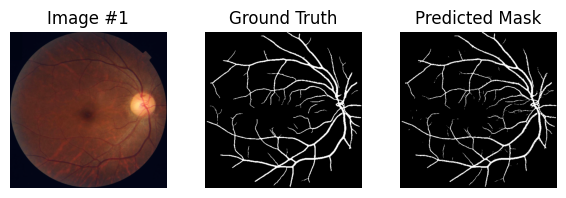

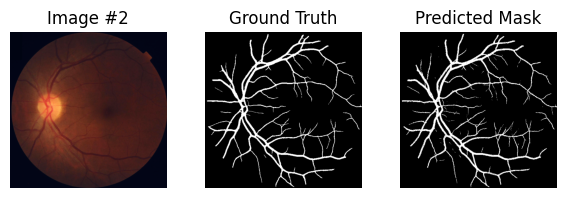

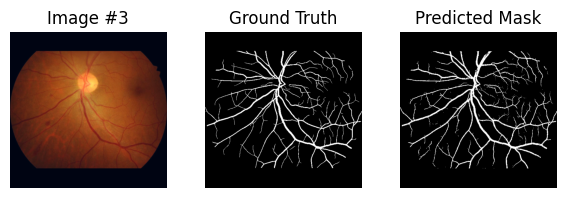

In [15]:
print("\n--- Starting Prediction and Comparative Visualization on the VALIDATION SET ---")
plot_validation_predictions(model, val_images, val_masks, num_samples=3)

In [16]:
import torch

@torch.no_grad()
def evaluate_f1(model, dataloader, threshold=0.5, device=None, return_global=True):
    """
    Computes mean per-image F1 on a dataloader of (images, masks) batches.
    Also returns mean Precision/Recall and (optionally) a global F1 over all pixels.

    Args:
        model: your RVGAN (or any model with .generator)
        dataloader: e.g., val_loader (yields [B,C,H,W] images, [B,1,H,W] masks)
        threshold: binarization threshold for predicted probabilities
        device: torch device; if None, inferred from model params
        return_global: if True, also compute a single F1 over all pixels

    Returns:
        {
          "mean_f1": float,
          "mean_precision": float,
          "mean_recall": float,
          "global_f1": float or None
        }
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()

    per_img_f1 = []
    per_img_prec = []
    per_img_rec = []

    # accumulators for global (micro) F1
    TP_all = torch.tensor(0.0, device=device)
    FP_all = torch.tensor(0.0, device=device)
    FN_all = torch.tensor(0.0, device=device)

    eps = 1e-8

    for images, masks in dataloader:
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True).float()  # [B,1,H,W] in {0,1}

        # Forward
        preds = model.generator(images)

        # If generator returns logits, squash; if already probs in [0,1], this is a no-op-ish
        if preds.min() < 0 or preds.max() > 1:
            preds = torch.sigmoid(preds)

        # Binarize
        pred_bin = (preds >= threshold).float()

        # Per-image TP/FP/FN
        # Flatten per image
        B = masks.shape[0]
        tp = (pred_bin * masks).view(B, -1).sum(dim=1)
        fp = (pred_bin * (1 - masks)).view(B, -1).sum(dim=1)
        fn = (((1 - pred_bin) * masks)).view(B, -1).sum(dim=1)

        precision = tp / (tp + fp + eps)
        recall    = tp / (tp + fn + eps)
        f1        = 2 * precision * recall / (precision + recall + eps)

        per_img_prec.append(precision.detach().cpu())
        per_img_rec.append(recall.detach().cpu())
        per_img_f1.append(f1.detach().cpu())

        # Global accumulators
        if return_global:
            TP_all += tp.sum()
            FP_all += fp.sum()
            FN_all += fn.sum()

    mean_precision = torch.cat(per_img_prec).mean().item()
    mean_recall    = torch.cat(per_img_rec).mean().item()
    mean_f1        = torch.cat(per_img_f1).mean().item()

    global_f1 = None
    if return_global:
        P = TP_all / (TP_all + FP_all + eps)
        R = TP_all / (TP_all + FN_all + eps)
        global_f1 = (2 * P * R / (P + R + eps)).item()

    return {
        "mean_f1": mean_f1,
        "mean_precision": mean_precision,
        "mean_recall": mean_recall,
        "global_f1": global_f1
    }

# --- Usage ---
# After training / when you have val_loader ready:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
model.to(device)
f1_stats = evaluate_f1(model, val_loader, threshold=0.5, device=device)
print(f"Val F1: {f1_stats['mean_f1']:.4f}  "
      f"(P={f1_stats['mean_precision']:.4f}, R={f1_stats['mean_recall']:.4f}, "
      f"global F1={f1_stats['global_f1']:.4f})")


Val F1: 0.8255  (P=0.8223, R=0.8437, global F1=0.8665)


[DEBUG] Dir pair:
  IMG: /home/lk57288c/DRIVE Dataset/DRIVE/training/images
  MSK: /home/lk57288c/DRIVE Dataset/DRIVE/training/1st_manual
  Found imgs=20 msks=20 -> paired=20
Test tensor shapes: images=torch.Size([20, 3, 512, 512]), masks=torch.Size([20, 1, 512, 512])


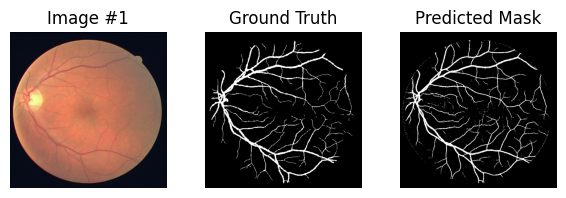

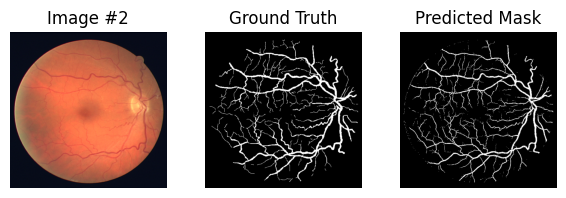

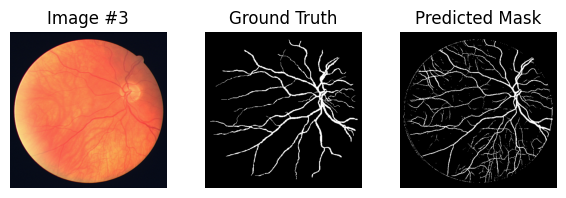

In [17]:

test_imgs_all, test_msks_all = gather_pairs(test_image_dirs, test_mask_dirs, image_extensions, debug=True)
# print(f"Test pairs: {len(test_imgs_all)}")
if len(test_imgs_all) == 0:
    raise RuntimeError("No test pairs found. Check your test_image_dirs/test_mask_dirs and extensions.")

# Create dataset/loader with EVAL transforms (no augmentation)
jt_eval = JointTransform(size=512, train=False)
ds_te   = RetinalDataset(test_imgs_all, test_msks_all, jt_eval)
te_loader = DataLoader(ds_te, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

# Materialize tensors [N,C,H,W] and [N,1,H,W]
test_images_list, test_masks_list = [], []
for imgs, msks in te_loader:
    test_images_list.append(imgs)  # [1,C,H,W]
    test_masks_list.append(msks)   # [1,1,H,W]

test_images = torch.cat(test_images_list, dim=0)  # [N,C,H,W]
test_masks  = torch.cat(test_masks_list,  dim=0)  # [N,1,H,W]
print(f"Test tensor shapes: images={test_images.shape}, masks={test_masks.shape}")

# Run the visualization on a few samples
device = next(model.parameters()).device
plot_validation_predictions(
    model,
    images_to_plot=test_images,
    true_masks=test_masks,
    num_samples=3,      # change as you like
    patch_size=128,
    stride=64,
    device=device
)


In [18]:

# If you already have test_loader from build_loaders(), this block will be skipped.
if 'test_loader' not in globals() or test_loader is None:
    # Pair test files and create a loader with EVAL transforms
    test_imgs_all, test_msks_all = gather_pairs(test_image_dirs, test_mask_dirs, image_extensions, debug=True)
    if len(test_imgs_all) == 0:
        raise RuntimeError("No test pairs found. Check test_image_dirs/test_mask_dirs and extensions.")
    jt_eval = JointTransform(size=512, train=False)
    ds_te   = RetinalDataset(test_imgs_all, test_msks_all, jt_eval)
    test_loader = DataLoader(ds_te, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

# Ensure model/device are set
device = next(model.parameters()).device

# Evaluate F1 (mean per-image + global/micro)
f1_stats = evaluate_f1(model, test_loader, threshold=0.5, device=device)

print(
    f"Test F1: {f1_stats['mean_f1']:.4f}  "
    f"(P={f1_stats['mean_precision']:.4f}, R={f1_stats['mean_recall']:.4f}, "
    f"global F1={f1_stats['global_f1']:.4f})"
)

Test F1: 0.7507  (P=0.7851, R=0.7224, global F1=0.7513)
